# Production-side analysis

The notebook 02 work covered **consumer amenities**: yoga, specialty coffee, wine bars, pilates, auto repair, print shops, Whole Foods. Those signals track businesses that serve the people *living in* a neighborhood.

This notebook covers the **production side**: businesses that physically build, sell, design, and service the city itself. The hypothesis behind treating these as their own group is that the production-side businesses follow a different rhythm than consumer amenities. Construction goes in waves driven by macro conditions (rates, lending, regulatory cycles); architects and designers cluster around upmarket capital flows; real-estate brokerages chase transaction volume. None of those rhythms map cleanly onto neighborhood gentrification stages the way a coffee shop's opening does.

Six signals here:
- `contractors` (leading) — renovation and general contractors, name-partition excludes 'construction'-named
- `design_economy` (leading) — architects + engineers + interior designers + design firms
- `real_estate_brokerages` (leading) — real estate dealers + services + real-estate development
- `construction_companies` (coincident) — name-partition takes 'construction'-named within general_contractor
- `landscaping` (coincident) — landscape gardeners + new-vocab name-recovery
- `skilled_trades` (coincident) — plumber + electrician + gas/HVAC, combined

**Address-of-work caveat (applies to all six).** Vancouver business licences register the *business address* (often a home or small office), not the *work address* (where building, designing, plumbing, landscaping actually happens). For the contractor / construction / trade / landscaping signals, geom coverage is 2-13% (vs 95%+ for storefront retail), and even those addresses are typically operator-residence. Spatial analysis at the neighborhood level reads as **where these businesses base themselves**, not where they work. This is its own interesting signal — neighborhoods that produce many contractors as residents tell us something about the city's labor geography — but it is **not** a measure of where construction or renovation is happening. Read every neighborhood-level chart in this notebook with that distinction in mind.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from datetime import date
import duckdb
import matplotlib.pyplot as plt
import polars as pl

from signals.leading.contractors import get_signal as get_contractors
from signals.leading.design_economy import get_signal as get_design_economy
from signals.leading.real_estate_brokerages import get_signal as get_real_estate
from signals.coincident.construction_companies import get_signal as get_construction
from signals.coincident.landscaping import get_signal as get_landscaping
from signals.coincident.skilled_trades import get_signal as get_skilled_trades
from signals.analytics import cohort_survival_curve, median_lifespan_by_cohort, n_year_survival_rate
from viz.style import apply as apply_style, signal_color

apply_style()

CHART_DIR = ROOT / 'analysis' / 'composite_index' / 'weekend_2_charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(ROOT / 'vancouver_signals.duckdb'), read_only=True)

SIGNALS = {
    'contractors': get_contractors,
    'design_economy': get_design_economy,
    'real_estate_brokerages': get_real_estate,
    'construction_companies': get_construction,
    'landscaping': get_landscaping,
    'skilled_trades': get_skilled_trades,
}

data = {name: fn(con).filter(~pl.col('is_left_censored')) for name, fn in SIGNALS.items()}
for name, df in data.items():
    print(f'  loaded {name}: {df.height:,} businesses (after dropping left-censored)')

  loaded contractors: 6,922 businesses (after dropping left-censored)
  loaded design_economy: 4,215 businesses (after dropping left-censored)
  loaded real_estate_brokerages: 2,396 businesses (after dropping left-censored)
  loaded construction_companies: 3,801 businesses (after dropping left-censored)
  loaded landscaping: 1,658 businesses (after dropping left-censored)
  loaded skilled_trades: 6,926 businesses (after dropping left-censored)


## Summary table

In [2]:
rows = []
for name, fn in SIGNALS.items():
    df = fn(con)
    rows.append({
        'signal': name,
        'class': df['signal_class'].unique().to_list()[0],
        'total': df.height,
        'pct_left_censored': round(100 * df['is_left_censored'].sum() / df.height, 1) if df.height else 0,
        'pct_with_closure': round(100 * df['closure_date'].is_not_null().sum() / df.height, 1) if df.height else 0,
    })
with pl.Config(tbl_cols=-1):
    print(pl.DataFrame(rows))

shape: (6, 5)
┌────────────────────────┬────────────┬───────┬───────────────────┬──────────────────┐
│ signal                 ┆ class      ┆ total ┆ pct_left_censored ┆ pct_with_closure │
│ ---                    ┆ ---        ┆ ---   ┆ ---               ┆ ---              │
│ str                    ┆ str        ┆ i64   ┆ f64               ┆ f64              │
╞════════════════════════╪════════════╪═══════╪═══════════════════╪══════════════════╡
│ contractors            ┆ leading    ┆ 7501  ┆ 7.7               ┆ 10.5             │
│ design_economy         ┆ leading    ┆ 4942  ┆ 14.7              ┆ 22.2             │
│ real_estate_brokerages ┆ leading    ┆ 2786  ┆ 14.0              ┆ 26.5             │
│ construction_companies ┆ coincident ┆ 4413  ┆ 13.9              ┆ 12.1             │
│ landscaping            ┆ coincident ┆ 2040  ┆ 18.7              ┆ 19.4             │
│ skilled_trades         ┆ coincident ┆ 8585  ┆ 19.3              ┆ 18.5             │
└────────────────────────┴───

## Methodology

Same definitions as notebook 02 (cohort = year of establishment_date, survival = closure_date null or > target year, right-censoring exclusion = drop cohorts younger than 3 years for cross-signal pooling, left-censoring filter pre-applied above). Two production-side specifics:

1. **Closure-rate caveat is heavier here.** Production-side businesses (contractors, trades, landscapers) renew differently from storefront retail; many lapse without filing a `Cancelled` or `Gone Out of Business` status. The notebook 02 yoga vs coffee gap discussion applies with even more force: closure-rate numbers in this notebook are likely lower bounds on actual closure activity. Read 5-year survival as an **upper bound on durability**, not a precise rate.
2. **Spatial analysis is per-business-address only.** Per the address-of-work caveat in the intro: there are no maps in this notebook. All charts are temporal. A future production-side spatial analysis would need building-permit data (where work is happening), not licence data (where licences are held).

In [3]:
def plot_signal_three_views(name, df, *, cohort_step=3, min_cohort_size=5):
    color = signal_color(name)

    cohort_years = sorted(df.with_columns(pl.col('establishment_date').dt.year().alias('y'))['y'].unique().to_list())
    sampled = [y for i, y in enumerate(cohort_years) if i % cohort_step == 0]
    today_year = date.today().year
    sampled = [y for y in sampled if y <= today_year - 3]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    cmap = plt.get_cmap('viridis')
    if sampled:
        for i, cy in enumerate(sampled):
            curve = cohort_survival_curve(df, cy, max_years=20)
            if int(curve['n_at_risk'][0]) < min_cohort_size:
                continue
            axes[0].plot(curve['years_since_opening'], curve['pct_surviving'],
                         label=str(cy), color=cmap(i / max(1, len(sampled) - 1)), alpha=0.85)
    axes[0].set_title(f'{name}: cohort survival curves')
    axes[0].set_xlabel('Years since opening')
    axes[0].set_ylabel('% surviving')
    axes[0].set_ylim(0, 1.05)
    if sampled:
        axes[0].legend(fontsize=8, ncol=2, loc='lower left', title='Cohort')

    ml = median_lifespan_by_cohort(df).filter(pl.col('median_lifespan_years').is_not_null())
    if ml.height:
        axes[1].plot(ml['cohort_year'], ml['median_lifespan_years'], color=color, marker='o', markersize=4)
    axes[1].set_title(f'{name}: median lifespan of closed businesses')
    axes[1].set_xlabel('Cohort year')
    axes[1].set_ylabel('Median lifespan (years)')

    surv = n_year_survival_rate(df, n_years=5)
    if surv.height:
        axes[2].plot(surv['cohort_year'], surv['pct_surviving_at_n'], color=color, marker='o', markersize=4)
    axes[2].set_title(f'{name}: 5-year survival by cohort')
    axes[2].set_xlabel('Cohort year')
    axes[2].set_ylabel('% still operating after 5 years')
    axes[2].set_ylim(0, 1.05)

    fig.tight_layout()
    out = CHART_DIR / f'production_{name}_survival.png'
    fig.savefig(out, bbox_inches='tight')
    print(f'  saved {out.relative_to(ROOT)}')
    plt.show()

## Contractors

  saved analysis/composite_index/weekend_2_charts/production_contractors_survival.png


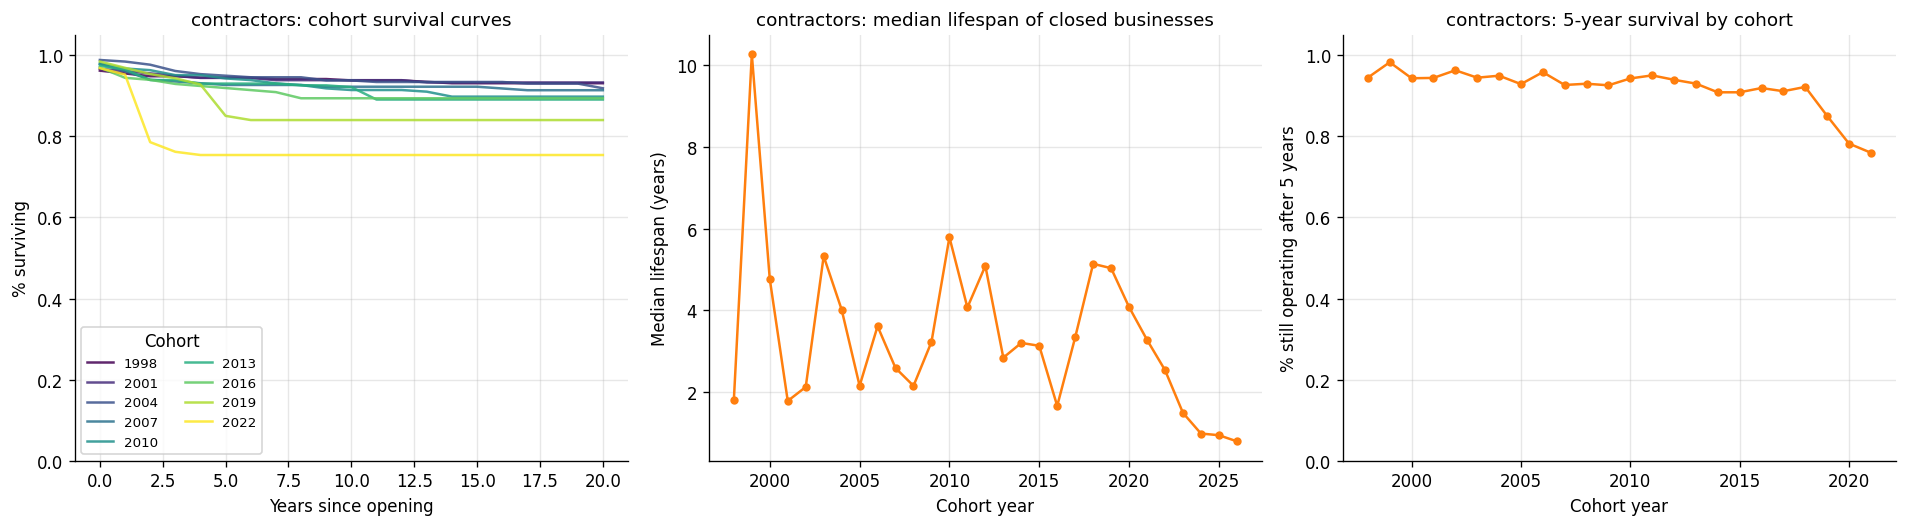

In [4]:
plot_signal_three_views('contractors', data['contractors'])

## Design economy

  saved analysis/composite_index/weekend_2_charts/production_design_economy_survival.png


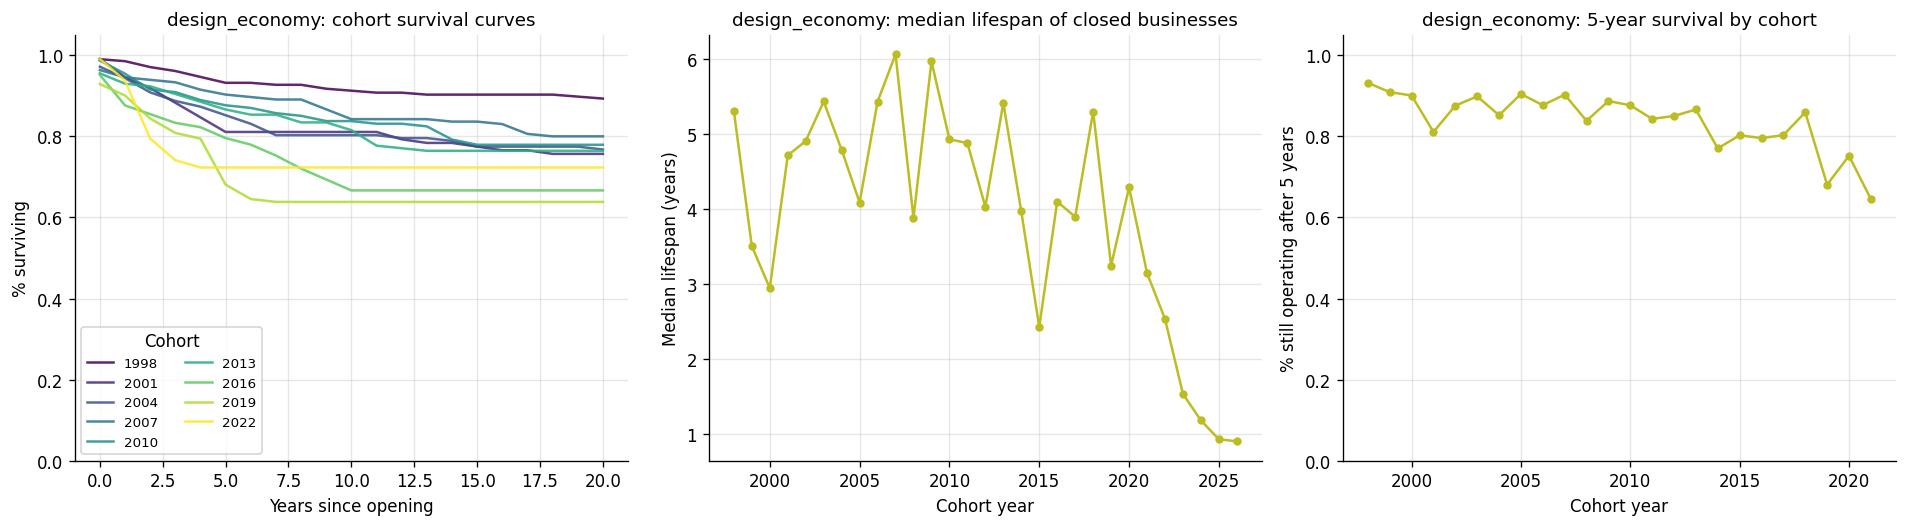

In [5]:
plot_signal_three_views('design_economy', data['design_economy'])

## Real estate brokerages

  saved analysis/composite_index/weekend_2_charts/production_real_estate_brokerages_survival.png


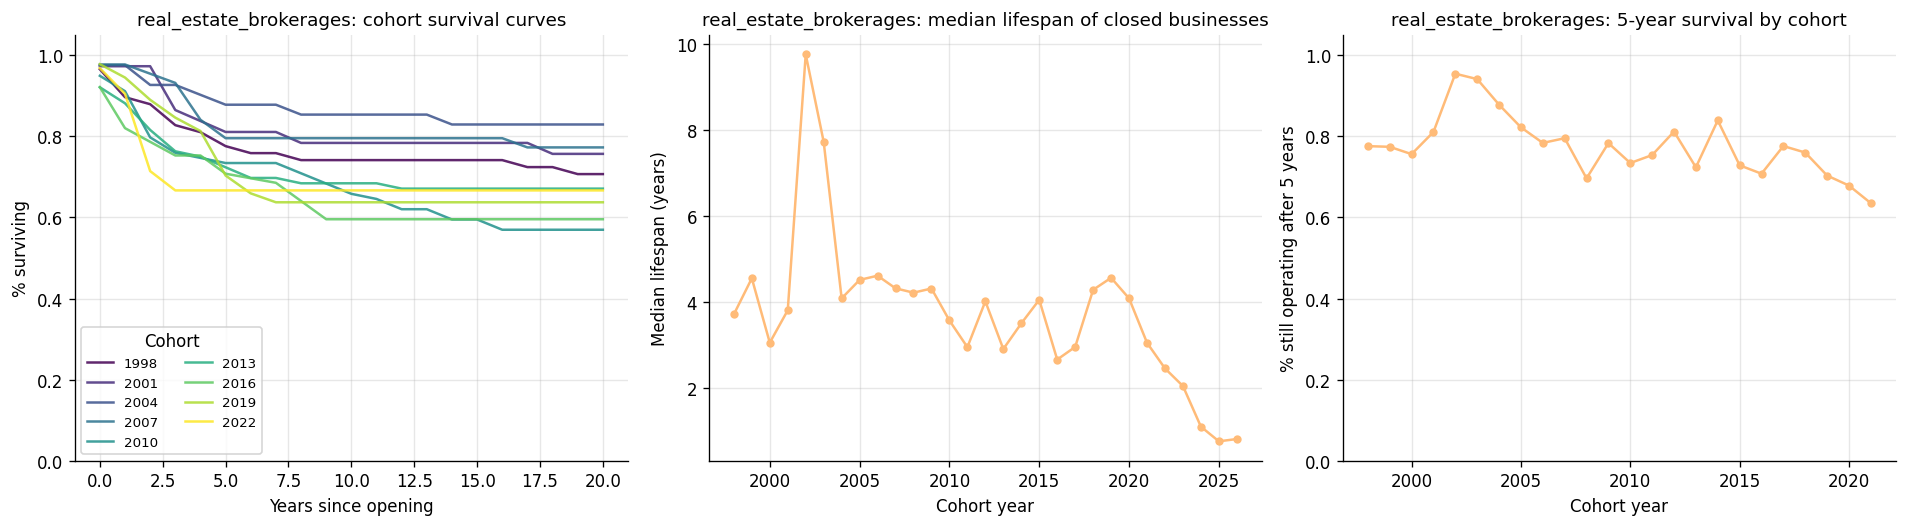

In [6]:
plot_signal_three_views('real_estate_brokerages', data['real_estate_brokerages'])

## Construction companies

  saved analysis/composite_index/weekend_2_charts/production_construction_companies_survival.png


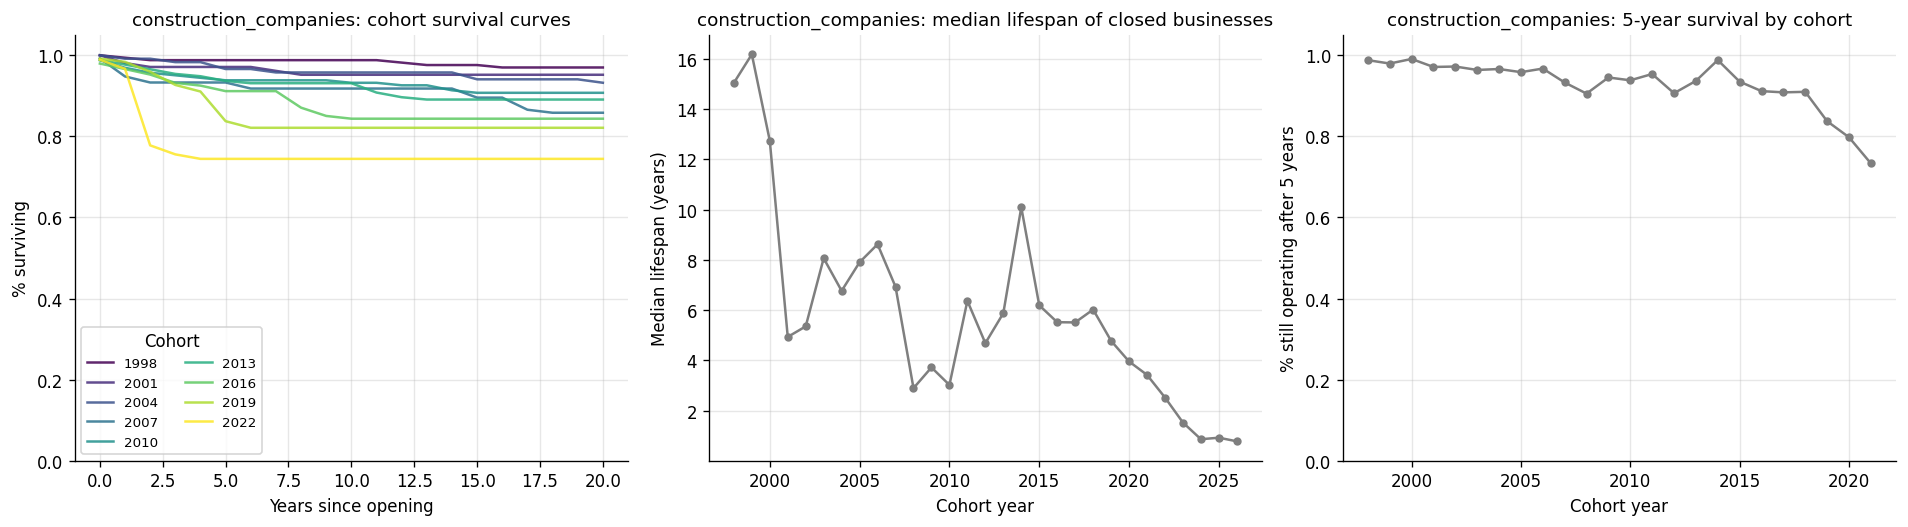

In [7]:
plot_signal_three_views('construction_companies', data['construction_companies'])

## Landscaping

  saved analysis/composite_index/weekend_2_charts/production_landscaping_survival.png


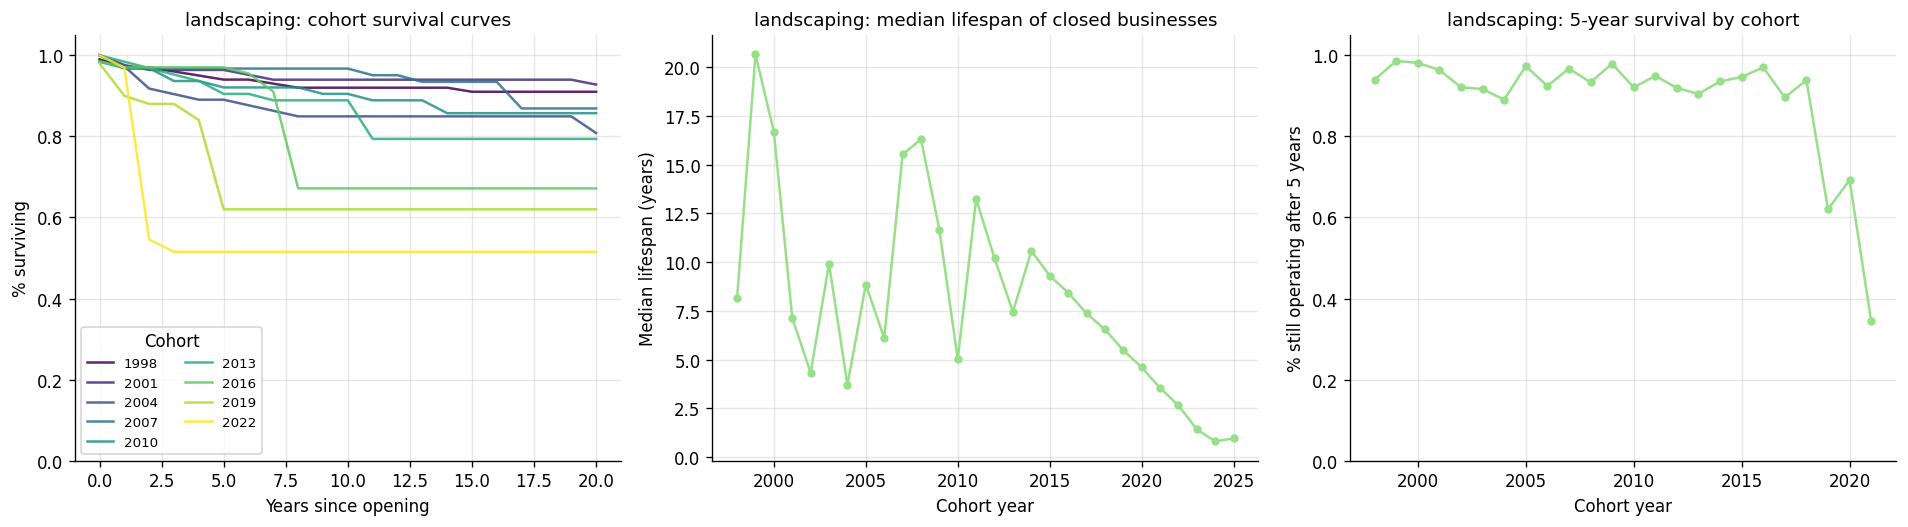

In [8]:
plot_signal_three_views('landscaping', data['landscaping'])

## Skilled trades (plumber + electrician + gas/HVAC)

  saved analysis/composite_index/weekend_2_charts/production_skilled_trades_survival.png


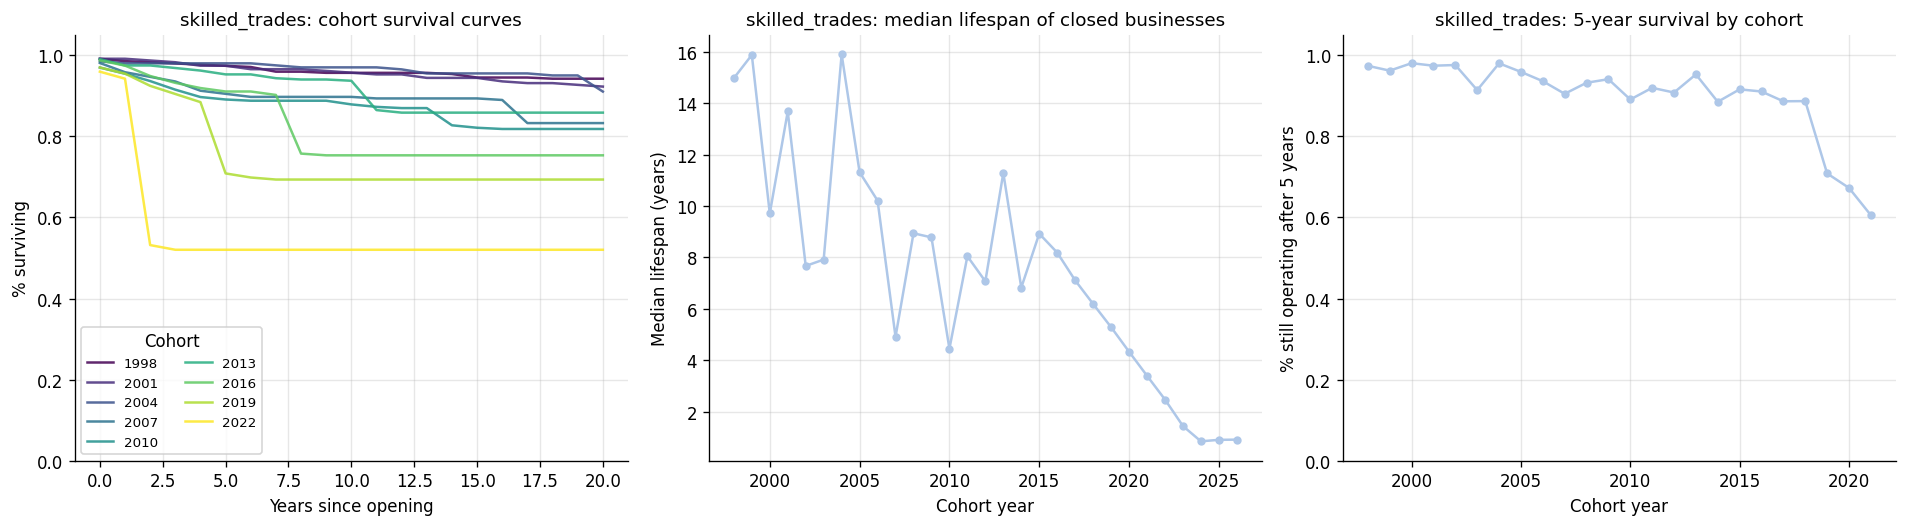

In [9]:
plot_signal_three_views('skilled_trades', data['skilled_trades'])

## Cross-signal comparison within the production side

shape: (6, 4)
┌────────────────────────┬────────────┬───────┬─────────┐
│ signal                 ┆ class      ┆ total ┆ pct_5yr │
│ ---                    ┆ ---        ┆ ---   ┆ ---     │
│ str                    ┆ str        ┆ i64   ┆ f64     │
╞════════════════════════╪════════════╪═══════╪═════════╡
│ construction_companies ┆ coincident ┆ 3317  ┆ 93.4    │
│ landscaping            ┆ coincident ┆ 1534  ┆ 91.3    │
│ skilled_trades         ┆ coincident ┆ 6180  ┆ 90.8    │
│ contractors            ┆ leading    ┆ 5242  ┆ 92.8    │
│ design_economy         ┆ leading    ┆ 3660  ┆ 84.0    │
│ real_estate_brokerages ┆ leading    ┆ 1588  ┆ 76.6    │
└────────────────────────┴────────────┴───────┴─────────┘
  saved analysis/composite_index/weekend_2_charts/production_5yr_survival_pooled.png


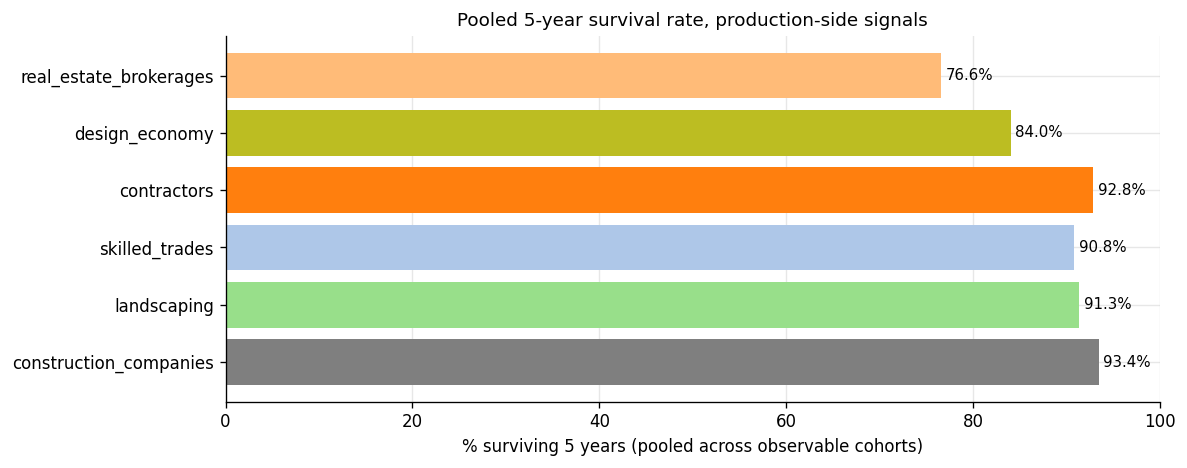

In [10]:
rows = []
for name, df in data.items():
    surv = n_year_survival_rate(df, n_years=5)
    if surv.height == 0:
        continue
    pooled_total = int(surv['n_total'].sum())
    pooled_alive = int(surv['n_surviving_at_n'].sum())
    rows.append({'signal': name, 'class': df['signal_class'].unique().to_list()[0],
                 'total': pooled_total, 'pct_5yr': round(100 * pooled_alive / pooled_total, 1) if pooled_total else 0})
pooled = pl.DataFrame(rows).sort(['class', 'pct_5yr'], descending=[False, True])
print(pooled)

fig, ax = plt.subplots(figsize=(10, 4))
names = pooled['signal'].to_list()
vals = pooled['pct_5yr'].to_list()
colors = [signal_color(n) for n in names]
ax.barh(names, vals, color=colors)
for i, v in enumerate(vals):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=9)
ax.set_title('Pooled 5-year survival rate, production-side signals')
ax.set_xlabel('% surviving 5 years (pooled across observable cohorts)')
ax.set_xlim(0, 100)
fig.tight_layout()
out = CHART_DIR / 'production_5yr_survival_pooled.png'
fig.savefig(out, bbox_inches='tight')
print(f'  saved {out.relative_to(ROOT)}')
plt.show()

  saved analysis/composite_index/weekend_2_charts/production_openings_per_year.png


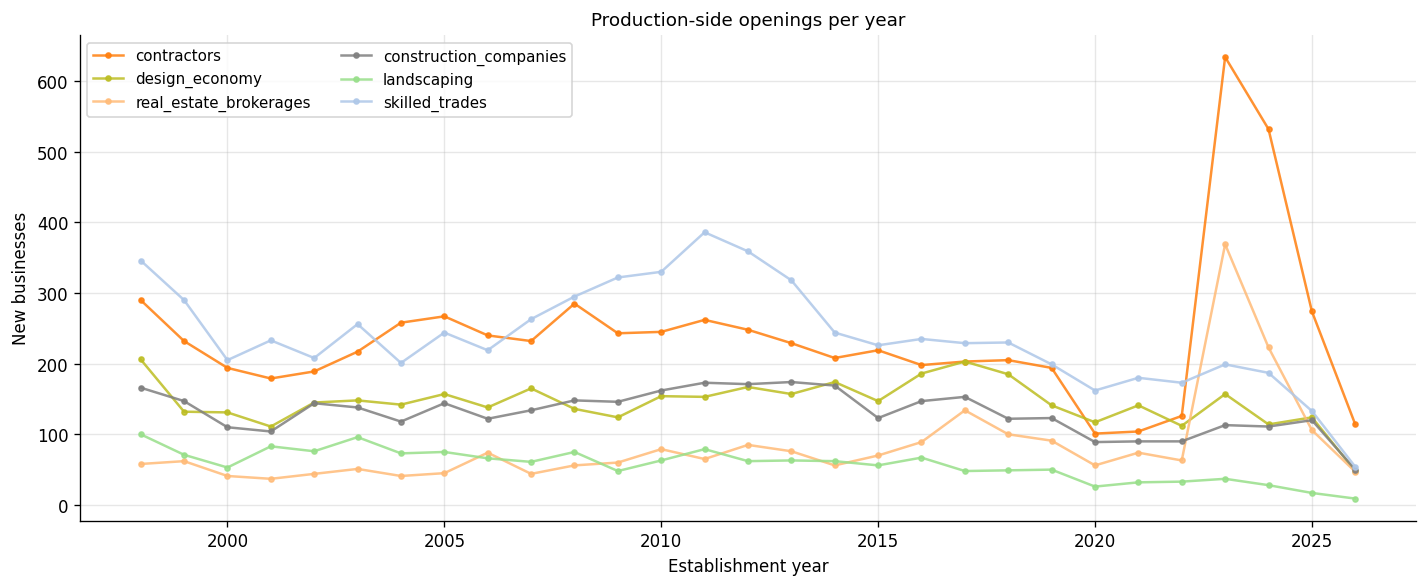

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, df in data.items():
    by_year = (df.with_columns(pl.col('establishment_date').dt.year().alias('year'))
                 .group_by('year').len().sort('year'))
    ax.plot(by_year['year'], by_year['len'], label=name, color=signal_color(name), marker='o', markersize=3, alpha=0.85)
ax.set_title('Production-side openings per year')
ax.set_xlabel('Establishment year')
ax.set_ylabel('New businesses')
ax.legend(fontsize=9, loc='upper left', ncol=2)
fig.tight_layout()
out = CHART_DIR / 'production_openings_per_year.png'
fig.savefig(out, bbox_inches='tight')
print(f'  saved {out.relative_to(ROOT)}')
plt.show()

  saved analysis/composite_index/weekend_2_charts/production_closures_per_year.png


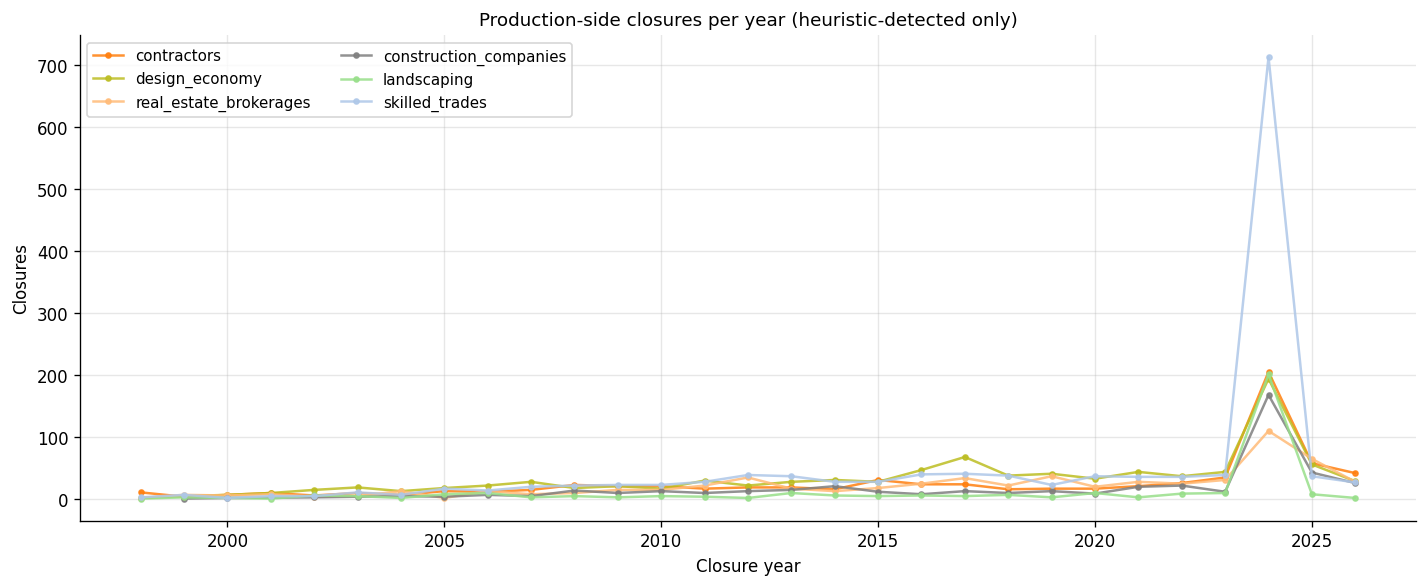

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, df in data.items():
    closed = df.filter(pl.col('closure_date').is_not_null())
    if closed.height == 0:
        continue
    by_year = (closed.with_columns(pl.col('closure_date').dt.year().alias('year'))
                     .group_by('year').len().sort('year'))
    ax.plot(by_year['year'], by_year['len'], label=name, color=signal_color(name), marker='o', markersize=3, alpha=0.85)
ax.set_title('Production-side closures per year (heuristic-detected only)')
ax.set_xlabel('Closure year')
ax.set_ylabel('Closures')
ax.legend(fontsize=9, loc='upper left', ncol=2)
fig.tight_layout()
out = CHART_DIR / 'production_closures_per_year.png'
fig.savefig(out, bbox_inches='tight')
print(f'  saved {out.relative_to(ROOT)}')
plt.show()

## Production-side-specific analyses

Building permits and housing-transaction data live in the MacroLens warehouse per `CLAUDE.md`. They aren't accessible from this session's environment, so the contractors-vs-permits and brokerages-vs-transactions cross-checks are deferred. Documented as future work in `weekend_2_batch_2_decisions.md`.

What we *can* do internally: compare opening velocity between trades and construction companies. The hypothesis is that skilled trades follow construction (lag) — when construction firms ramp up, plumbers and electricians expand to staff the work.

  saved analysis/composite_index/weekend_2_charts/production_trades_vs_construction.png


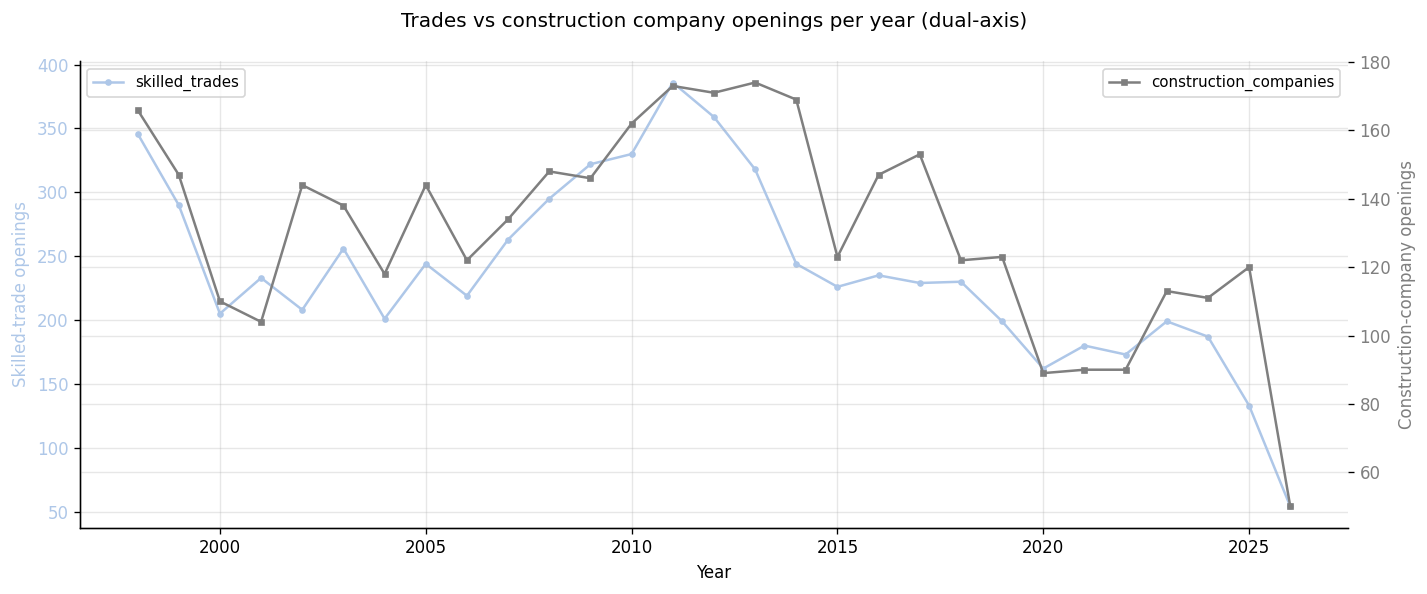


Lag/lead correlation between trades and construction openings:
  k=-3 (trades leads construction by 3yr): r=0.350
  k=-2 (trades leads construction by 2yr): r=0.456
  k=-1 (trades leads construction by 1yr): r=0.610
  k=+0 (concurrent): r=0.866
  k=+1 (construction leads trades by 1yr): r=0.797
  k=+2 (construction leads trades by 2yr): r=0.603
  k=+3 (construction leads trades by 3yr): r=0.489


In [13]:
def yearly_openings(df):
    return (df.with_columns(pl.col('establishment_date').dt.year().alias('year'))
              .group_by('year').len().sort('year').rename({'len': 'openings'}))

trades_yr = yearly_openings(data['skilled_trades'])
constr_yr = yearly_openings(data['construction_companies'])

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(trades_yr['year'], trades_yr['openings'], label='skilled_trades', color=signal_color('skilled_trades'), marker='o', markersize=3)
ax1.set_xlabel('Year')
ax1.set_ylabel('Skilled-trade openings', color=signal_color('skilled_trades'))
ax1.tick_params(axis='y', labelcolor=signal_color('skilled_trades'))
ax2 = ax1.twinx()
ax2.plot(constr_yr['year'], constr_yr['openings'], label='construction_companies', color=signal_color('construction_companies'), marker='s', markersize=3)
ax2.set_ylabel('Construction-company openings', color=signal_color('construction_companies'))
ax2.tick_params(axis='y', labelcolor=signal_color('construction_companies'))
fig.suptitle('Trades vs construction company openings per year (dual-axis)')
ax1.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
fig.tight_layout()
out = CHART_DIR / 'production_trades_vs_construction.png'
fig.savefig(out, bbox_inches='tight')
print(f'  saved {out.relative_to(ROOT)}')
plt.show()

# Lag/lead correlation: pearson between trades(year) and construction(year-k) for k in -3..+3
import numpy as np
merged = trades_yr.join(constr_yr, on='year', how='inner', suffix='_constr')
trades_vals = np.array(merged['openings'].to_list(), dtype=float)
constr_vals = np.array(merged['openings_constr'].to_list(), dtype=float)
print('\nLag/lead correlation between trades and construction openings:')
for k in range(-3, 4):
    if k < 0:
        a, b = trades_vals[-k:], constr_vals[:k]
    elif k > 0:
        a, b = trades_vals[:-k], constr_vals[k:]
    else:
        a, b = trades_vals, constr_vals
    if len(a) > 2 and a.std() > 0 and b.std() > 0:
        r = np.corrcoef(a, b)[0, 1]
        if k < 0:
            label = f'trades leads construction by {-k}yr'
        elif k > 0:
            label = f'construction leads trades by {k}yr'
        else:
            label = 'concurrent'
        print(f'  k={k:+d} ({label}): r={r:.3f}')

## Findings

(Filled in after reviewing the charts above. The key things to look for:)

1. **Pooled survival ranking within production side.** Which production-side signal is most durable? Hypothesis: real-estate brokerages (white-collar, low fixed cost) > design_economy > contractors > construction companies > trades > landscaping (mobile, low barrier to entry, high churn). If skilled_trades and landscaping show the lowest 5-year survival, that aligns with their high-churn nature; if they show high survival, it's a sign that the closure heuristic is missing trade-business lapses.
2. **Total production-side openings over time.** When was Vancouver's production side booming? When was it busting? The aggregate openings curve should show waves correlated with macro construction cycles.
3. **Trades vs construction lag/lead.** Per the lag-correlation output: do trades follow construction? If `r` peaks at k=+1 or +2 (construction leads trades), the labor force expanded after the work started. If `r` peaks at k=0, they moved together. If trades lead, that's surprising and worth investigating.

**What this notebook can't say.** Without building-permit data, we don't know if production-side openings actually correlate with construction *activity* (they might just track licence-registration cycles). Without housing-transaction data, real-estate brokerage trends can't be tied to actual sales volume. These are the next-tier data sources to bring in.

**Compared to consumer amenities (notebook 02).** The big surface comparison: production-side businesses tend to have lower closure rates (10-20%) than consumer amenities (24-60%). Three explanations are plausible: (a) production businesses really are more durable; (b) production businesses lapse without filing closure paperwork at higher rates; (c) production licences renew on different timelines and our heuristic catches fewer of them. The yoga spot-check work bears on this question — if yoga's apparent durability turns out to be an artifact of under-detected lapses, the same caveat applies harder to trades and contractors.